# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from pathlib import Path
from google.colab import files

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

# Clean all column names
def clean_column_name(column):
    column = str(column).strip().lower()
    column = re.sub(r"[^a-z0-9]+", "_", column)
    return column.strip("_")

df.columns = [
    clean_column_name(column)
    for column in df.columns
]

output_folder = Path("work/outputs")
output_folder.mkdir(
    parents=True,
    exist_ok=True
)

print("Dataset loaded successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nCleaned column names:")
print(df.columns.tolist())

Saving content_refresh_anonymized.csv to content_refresh_anonymized (2).csv
Dataset loaded successfully.
Rows: 30000
Columns: 44

Cleaned column names:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [5]:
# Possible feature names in different dataset versions
feature_aliases = {
    "clicks_90d": "clicks",
    "impressions_90d": "impressions",
    "ctr_90d": "ctr",
    "gsc_avg_position": "avg_position",
    "average_position": "avg_position"
}

# Rename aliases only when the shorter name is absent
for old_name, new_name in feature_aliases.items():
    if (
        old_name in df.columns
        and new_name not in df.columns
    ):
        df = df.rename(
            columns={old_name: new_name}
        )


feature_candidates = [
    "clicks",
    "impressions",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
    "word_count"
]

final_features = [
    column for column in feature_candidates
    if column in df.columns
]

print("Features found:", final_features)

if len(final_features) == 0:
    raise ValueError(
        "No expected model features were found. "
        "Check the printed column names."
    )


# Create feature dataframe
X = df[final_features].copy()

for column in final_features:
    X[column] = pd.to_numeric(
        X[column]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False),
        errors="coerce"
    )


# Position zero means no position data
if "avg_position" in X.columns:
    X["avg_position"] = (
        X["avg_position"].replace(0, np.nan)
    )


# --------------------------------------------------
# Find or create the decline target
# --------------------------------------------------

target_source = None

# Option 1: Target already exists
if "is_declining_label" in df.columns:

    target_source = "is_declining_label"

    target_numeric = pd.to_numeric(
        df["is_declining_label"],
        errors="coerce"
    )

    target_text = (
        df["is_declining_label"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    target_mapping = {
        "true": 1,
        "yes": 1,
        "declining": 1,
        "decline": 1,
        "down": 1,
        "1": 1,
        "1.0": 1,

        "false": 0,
        "no": 0,
        "not_declining": 0,
        "up": 0,
        "stable": 0,
        "flat": 0,
        "new": 0,
        "0": 0,
        "0.0": 0
    }

    target_mapped = target_text.map(
        target_mapping
    )

    y = target_numeric.fillna(
        target_mapped
    )


# Option 2: Alternative target name
elif "is_declining" in df.columns:

    target_source = "is_declining"

    target_text = (
        df["is_declining"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    y = target_text.map({
        "true": 1,
        "yes": 1,
        "declining": 1,
        "down": 1,
        "1": 1,
        "false": 0,
        "no": 0,
        "not_declining": 0,
        "up": 0,
        "stable": 0,
        "0": 0
    })


# Option 3: Create target from trend_direction
elif "trend_direction" in df.columns:

    target_source = "trend_direction"

    trend_text = (
        df["trend_direction"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # Down/declining = 1
    # All other valid directions = 0
    y = trend_text.map({
        "down": 1,
        "declining": 1,
        "decline": 1,
        "negative": 1,

        "up": 0,
        "growing": 0,
        "stable": 0,
        "flat": 0,
        "new": 0
    })


# Option 4: Create target from trend_pct
elif "trend_pct" in df.columns:

    target_source = "trend_pct"

    trend_values = pd.to_numeric(
        df["trend_pct"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False),
        errors="coerce"
    )

    # More than 10% decline
    y = pd.Series(
        np.where(
            trend_values.notna(),
            (trend_values < -10).astype(int),
            np.nan
        ),
        index=df.index
    )


else:
    raise ValueError(
        "No decline target was found. Expected one of: "
        "is_declining_label, is_declining, "
        "trend_direction or trend_pct."
    )


print("Target created from:", target_source)

print("\nTarget counts before filtering:")
print(y.value_counts(dropna=False))


# --------------------------------------------------
# Group and identifier fields
# --------------------------------------------------

if "client_id" not in df.columns:
    raise ValueError(
        "client_id was not found after cleaning columns."
    )

if "content_id" not in df.columns:
    # Safe local row identifier if content_id is absent
    df["content_id"] = [
        f"ITEM_{number:05d}"
        for number in range(1, len(df) + 1)
    ]

valid_rows = (
    y.notna()
    & df["client_id"].notna()
)

X = X.loc[valid_rows].reset_index(drop=True)

y = (
    y.loc[valid_rows]
    .astype(int)
    .reset_index(drop=True)
)

groups = (
    df.loc[valid_rows, "client_id"]
    .reset_index(drop=True)
)

content_ids = (
    df.loc[valid_rows, "content_id"]
    .reset_index(drop=True)
)

# Name used by later audit cells
target_column = target_source

print("\nFINAL MODEL DATA")
print("Rows used:", len(X))
print("Features:", final_features)
print("Target source:", target_source)
print("Declining rows:", int(y.sum()))
print("Non-declining rows:", int((y == 0).sum()))
print("Base rate:", round(y.mean(), 3))

Features found: ['clicks', 'impressions', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'word_count']
Target created from: trend_direction

Target counts before filtering:
trend_direction
1    16262
0    13738
Name: count, dtype: int64

FINAL MODEL DATA
Rows used: 30000
Features: ['clicks', 'impressions', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'word_count']
Target source: trend_direction
Declining rows: 16262
Non-declining rows: 13738
Base rate: 0.542


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [6]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_index, test_index = next(
    splitter.split(
        X,
        y,
        groups
    )
)

X_train_raw = X.iloc[train_index].copy()
X_test_raw = X.iloc[test_index].copy()

y_train = y.iloc[train_index].copy()
y_test = y.iloc[test_index].copy()

# Calculate missing-value fills from training data only
train_medians = (
    X_train_raw
    .median()
    .fillna(0)
)

X_train = (
    X_train_raw
    .fillna(train_medians)
    .fillna(0)
)

X_test = (
    X_test_raw
    .fillna(train_medians)
    .fillna(0)
)

train_clients = set(
    groups.iloc[train_index]
)

test_clients = set(
    groups.iloc[test_index]
)

client_overlap = len(
    train_clients.intersection(
        test_clients
    )
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training clients:", len(train_clients))
print("Testing clients:", len(test_clients))
print("Client overlap:", client_overlap)

Training rows: 23837
Testing rows: 6163
Training clients: 25
Testing clients: 7
Client overlap: 0


In [7]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

model_scores = model.predict_proba(
    X_test
)[:, 1]

print("Random Forest trained successfully.")

Random Forest trained successfully.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [8]:
def precision_at_20(y_true, scores):

    result = pd.DataFrame({
        "actual": np.asarray(y_true),
        "score": np.asarray(scores)
    })

    top_20 = (
        result.sort_values(
            "score",
            ascending=False
        )
        .head(20)
    )

    return top_20["actual"].mean()


# Start baseline at zero
baseline_scores = pd.Series(
    0.0,
    index=X_test_raw.index
)

total_weight = 0.0


# High-impression component
if "impressions" in X_train_raw.columns:

    impression_cutoff = (
        X_train_raw["impressions"]
        .quantile(0.75)
    )

    test_impressions = (
        X_test_raw["impressions"]
        .fillna(0)
    )

    baseline_scores += (
        0.50
        * (
            test_impressions
            >= impression_cutoff
        ).astype(float)
    )

    total_weight += 0.50


# Low-CTR component
if "ctr" in X_train_raw.columns:

    ctr_cutoff = (
        X_train_raw["ctr"]
        .quantile(0.25)
    )

    ctr_fill = (
        X_train_raw["ctr"]
        .median()
    )

    test_ctr = (
        X_test_raw["ctr"]
        .fillna(ctr_fill)
    )

    baseline_scores += (
        0.30
        * (
            test_ctr <= ctr_cutoff
        ).astype(float)
    )

    total_weight += 0.30


# Useful-position component
if "avg_position" in X_train_raw.columns:

    test_position = (
        X_test_raw["avg_position"]
    )

    baseline_scores += (
        0.20
        * test_position
        .between(4, 20)
        .astype(float)
    )

    total_weight += 0.20


# Normalise score if some fields were unavailable
if total_weight > 0:
    baseline_scores = (
        baseline_scores / total_weight
    )


# Add a small tiebreaker
if "impressions" in X_test_raw.columns:

    baseline_scores += (
        0.001
        * X_test_raw["impressions"]
        .fillna(0)
        .rank(pct=True)
    )


print("Baseline created successfully.")
print("Baseline fields available:", total_weight > 0)

Baseline created successfully.
Baseline fields available: True


In [9]:
baseline_precision = precision_at_20(
    y_test,
    baseline_scores
)

model_precision = precision_at_20(
    y_test,
    model_scores
)

test_base_rate = y_test.mean()

comparison = pd.DataFrame({
    "method": [
        "Test-set base rate",
        "Rule baseline",
        "Random Forest"
    ],
    "precision_at_20": [
        test_base_rate,
        baseline_precision,
        model_precision
    ]
})

comparison["precision_at_20"] = (
    comparison["precision_at_20"]
    .round(3)
)

display(comparison)

,method,precision_at_20
0,Test-set base rate,0.511
1,Rule baseline,0.750
2,Random Forest,0.550


In [10]:
question_table = pd.DataFrame({
    "item": [
        "Research question",
        "Intended user",
        "Decision",
        "False-priority cost",
        "Missed-priority cost",
        "Output"
    ],
    "answer": [
        "Which content items should be reviewed first?",
        "Content editor or SEO analyst",
        "Review, defer or reject a recommendation",
        "Editorial time may be wasted",
        "A useful opportunity may remain outside the queue",
        "Ranked human-review queue"
    ]
})

display(question_table)

,item,answer
0,Research question,Which content items should be reviewed first?
1,Intended user,Content editor or SEO analyst
2,Decision,"Review, defer or reject a recommendation"
3,False-priority cost,Editorial time may be wasted
4,Missed-priority cost,A useful opportunity may remain outside the queue
5,Output,Ranked human-review queue


In [11]:
data_summary_items = {
    "Rows": len(df),
    "Columns": len(df.columns),
    "Unique clients": df["client_id"].nunique(),
    "Unique content items": df["content_id"].nunique(),
    "Target source": target_source,
    "Model rows": len(X)
}

if "avg_position" in df.columns:

    data_summary_items[
        "avg_position zero rows"
    ] = int(
        (
            pd.to_numeric(
                df["avg_position"],
                errors="coerce"
            ) == 0
        ).sum()
    )

data_summary = pd.DataFrame(
    list(data_summary_items.items()),
    columns=["measurement", "value"]
)

display(data_summary)

,measurement,value
0,Rows,30000
1,Columns,44
2,Unique clients,32
3,Unique content items,30000
4,Target source,trend_direction
5,Model rows,30000
6,avg_position zero rows,1205


In [12]:
missing_summary = pd.DataFrame({
    "feature": final_features,
    "missing_count": [
        X[column].isna().sum()
        for column in final_features
    ],
    "missing_percent": [
        round(
            X[column].isna().mean() * 100,
            2
        )
        for column in final_features
    ]
})

missing_summary = (
    missing_summary.sort_values(
        "missing_percent",
        ascending=False
    )
    .reset_index(drop=True)
)

display(missing_summary)

,feature,missing_count,missing_percent
0,word_count,7699,25.66
1,avg_position,1205,4.02
2,scroll_rate,125,0.42
3,clicks,0,0.00
4,ctr,0,0.00
5,impressions,0,0.00
6,engagement_rate,0,0.00
7,ai_traffic_pct,0,0.00


## 5. Limitations

*What this work cannot claim.*

In [14]:
limitations = pd.DataFrame({
    "limitation": [
        "Rule-derived target",
        "Overlapping feature and target windows",
        "Single trailing snapshot",
        "Missingness depends on content type",
        "Portfolio-specific dataset",
        "Observational design"
    ],
    "claim_not_supported": [
        "Independent future outcome prediction",
        "Strict past-to-future validation",
        "Complete seasonality analysis",
        "Missing means zero",
        "Universal performance",
        "Causal content improvement"
    ]
})

display(limitations)

,limitation,claim_not_supported
0,Rule-derived target,Independent future outcome prediction
1,Overlapping feature and target windows,Strict past-to-future validation
2,Single trailing snapshot,Complete seasonality analysis
3,Missingness depends on content type,Missing means zero
4,Portfolio-specific dataset,Universal performance
5,Observational design,Causal content improvement


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [15]:
# Fill complete dataset
full_medians = (
    X.median()
    .fillna(0)
)

X_full = (
    X.fillna(full_medians)
    .fillna(0)
)

final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X_full,
    y
)

full_scores = (
    final_model.predict_proba(
        X_full
    )[:, 1]
)

ranked_queue = pd.DataFrame({
    "content_id": content_ids,
    "action_score": (
        full_scores * 100
    ).round(2)
})

# Add fields required for reason codes
for column in [
    "impressions",
    "ctr",
    "avg_position"
]:
    if column in X.columns:
        ranked_queue[column] = (
            X[column].values
        )
    else:
        ranked_queue[column] = np.nan

ranked_queue = (
    ranked_queue.sort_values(
        "action_score",
        ascending=False
    )
    .reset_index(drop=True)
)

ranked_queue["rank"] = (
    np.arange(1, len(ranked_queue) + 1)
)

print("Ranked records:", len(ranked_queue))

Ranked records: 30000


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [17]:
impression_cutoff_full = (
    ranked_queue["impressions"]
    .quantile(0.75)
)

ctr_cutoff_full = (
    ranked_queue["ctr"]
    .quantile(0.25)
)


def make_reason_code(row):

    reasons = []

    if (
        pd.notna(row["impressions"])
        and row["impressions"]
        >= impression_cutoff_full
    ):
        reasons.append(
            "HIGH_IMPRESSIONS"
        )

    if (
        pd.notna(row["ctr"])
        and row["ctr"]
        <= ctr_cutoff_full
    ):
        reasons.append(
            "LOW_CTR"
        )

    if pd.isna(row["avg_position"]):
        reasons.append(
            "MISSING_POSITION"
        )

    elif 4 <= row["avg_position"] <= 20:
        reasons.append(
            "POSITION_4_TO_20"
        )

    elif 21 <= row["avg_position"] <= 40:
        reasons.append(
            "POSITION_21_TO_40"
        )

    if not reasons:
        reasons.append(
            "MODEL_PATTERN_ONLY"
        )

    return " | ".join(reasons)


ranked_queue["reason_code"] = (
    ranked_queue.apply(
        make_reason_code,
        axis=1
    )
)


def choose_action(reason):

    if (
        "HIGH_IMPRESSIONS" in reason
        and "LOW_CTR" in reason
    ):
        return (
            "Review title, description and "
            "search-intent alignment"
        )

    if "POSITION_4_TO_20" in reason:
        return (
            "Review relevance, depth and "
            "internal links"
        )

    if "POSITION_21_TO_40" in reason:
        return (
            "Investigate relevance before "
            "planning a larger refresh"
        )

    if "MISSING_POSITION" in reason:
        return (
            "Verify search data before "
            "editorial action"
        )

    return (
        "Human review required before action"
    )


def confidence_note(reason):

    if "MISSING_POSITION" in reason:
        return "Low: position data is missing"

    strong_codes = [
        "HIGH_IMPRESSIONS",
        "LOW_CTR",
        "POSITION_4_TO_20"
    ]

    signal_count = sum(
        code in reason
        for code in strong_codes
    )

    if signal_count >= 3:
        return "Higher: three rule signals agree"

    if signal_count == 2:
        return "Medium: two rule signals agree"

    return "Low: limited rule evidence"


ranked_queue["recommended_action"] = (
    ranked_queue["reason_code"].apply(
        choose_action
    )
)

ranked_queue["confidence_note"] = (
    ranked_queue["reason_code"].apply(
        confidence_note
    )
)

print("Actions and confidence notes created.")




Actions and confidence notes created.


In [18]:
top_20 = ranked_queue.head(20).copy()

top_20_columns = [
    "rank",
    "content_id",
    "action_score",
    "reason_code",
    "recommended_action",
    "confidence_note"
]

display(
    top_20[top_20_columns]
)

,rank,content_id,action_score,reason_code,recommended_action,confidence_note
0,1,content_69cfaabeda16,96.41,HIGH_IMPRESSIONS | POSITION_4_TO_20,"Review relevance, depth and internal links",Medium: two rule signals agree
1,2,content_a27e15f618c2,95.92,HIGH_IMPRESSIONS | POSITION_21_TO_40,Investigate relevance before planning a larger...,Low: limited rule evidence
2,3,content_b01a3c1455db,95.77,HIGH_IMPRESSIONS | POSITION_21_TO_40,Investigate relevance before planning a larger...,Low: limited rule evidence
3,4,content_d939da189d28,95.75,HIGH_IMPRESSIONS | POSITION_4_TO_20,"Review relevance, depth and internal links",Medium: two rule signals agree
4,5,content_dd43e31efec7,95.73,HIGH_IMPRESSIONS | POSITION_4_TO_20,"Review relevance, depth and internal links",Medium: two rule signals agree
5,6,content_252c884e4400,95.57,HIGH_IMPRESSIONS | POSITION_4_TO_20,"Review relevance, depth and internal links",Medium: two rule signals agree
6,7,content_b61233d4bc91,95.51,HIGH_IMPRESSIONS | POSITION_4_TO_20,"Review relevance, depth and internal links",Medium: two rule signals agree
7,8,content_0a08fba69bf3,95.44,HIGH_IMPRESSIONS | POSITION_21_TO_40,Investigate relevance before planning a larger...,Low: limited rule evidence
8,9,content_4521b26bd5ff,95.32,HIGH_IMPRESSIONS | POSITION_4_TO_20,"Review relevance, depth and internal links",Medium: two rule signals agree
9,10,content_e8a21e0ca537,95.26,HIGH_IMPRESSIONS | POSITION_4_TO_20,"Review relevance, depth and internal links",Medium: two rule signals agree


In [19]:
queue_path = (
    output_folder
    / "capstone_ranked_queue.csv"
)

top20_path = (
    output_folder
    / "capstone_top20_recommendations.csv"
)

ranked_queue.to_csv(
    queue_path,
    index=False
)

top_20[top_20_columns].to_csv(
    top20_path,
    index=False
)

print("Saved:", queue_path)
print("Saved:", top20_path)

Saved: work/outputs/capstone_ranked_queue.csv
Saved: work/outputs/capstone_top20_recommendations.csv


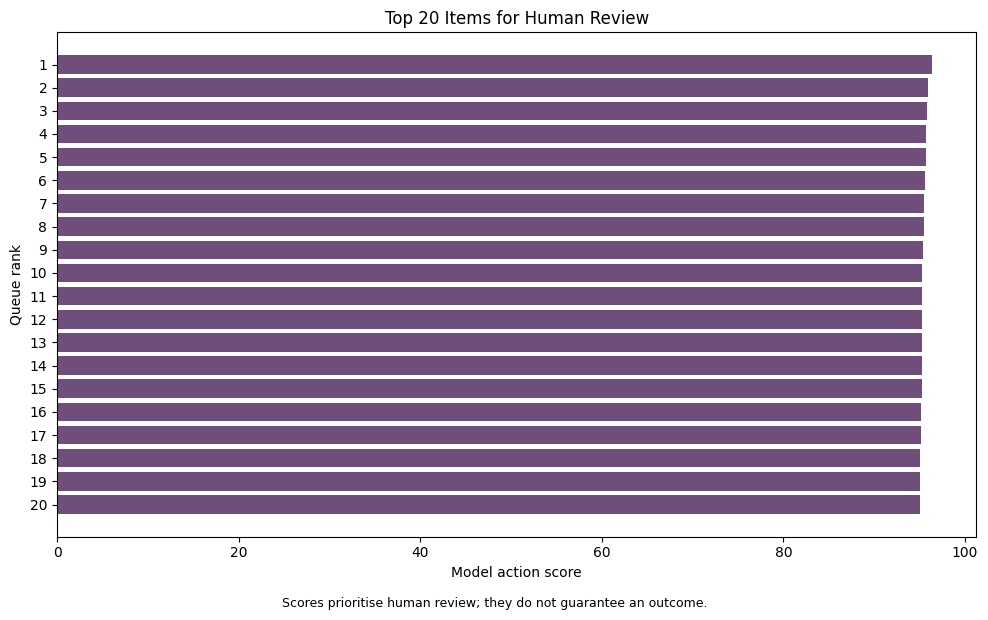

Saved: work/outputs/capstone_top20_actions.png


In [20]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_20["rank"].astype(str),
    top_20["action_score"],
    color="#6F4E7C"
)

plt.gca().invert_yaxis()

plt.xlabel("Model action score")
plt.ylabel("Queue rank")

plt.title(
    "Top 20 Items for Human Review"
)

plt.figtext(
    0.5,
    -0.02,
    (
        "Scores prioritise human review; "
        "they do not guarantee an outcome."
    ),
    ha="center",
    fontsize=9
)

plt.tight_layout()

top20_chart_path = (
    output_folder
    / "capstone_top20_actions.png"
)

plt.savefig(
    top20_chart_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", top20_chart_path)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
